# T07 PSM -- 政府补贴对企业研发投入的效应

## 0. 论文信息

| 字段 | 内容 |
|------|------|
| **论文题目** | 政治联系、寻租与地方政府财政补贴有效性 |
| **作者** | 余明桂, 回雅甫, 潘红波 |
| **期刊** | 《经济研究》(3), 65-77, 2010 |
| **核心问题** | 政府补贴是否真正提升企业R&D投入？ |
| **方法** | PSM，Logit倾向得分 + 最近邻卡尺匹配 + ATT估计 |

## 1. 研究设计

获补贴企业往往规模更大、盈利更好，即便不获补贴R&D投入本来就更高。
PSM为每个受补贴企业找倾向得分相近的对照企业，消除可观测选择偏差。

$$\text{ATT} = E[Y(1)-Y(0)|T=1]$$

## 2. 数学理论

**倾向得分**：$e(\mathbf{x}) = P(T_i=1|X_i=\mathbf{x})$，Logit估计

**CIA条件**：$Y(0),Y(1) \perp T | \mathbf{X}$

**共同支撑**：$0 < P(T=1|\mathbf{X}) < 1$

## 3. 数据加载与预处理

In [1]:
import sys, io, re as _re
from pathlib import Path

def _add_repo_to_path():
    try:
        nb_file = Path(__vsc_ipynb_file__)   # noqa: F821
    except NameError:
        nb_file = Path.cwd() / '_dummy.ipynb'
    for p in [nb_file.parent, *nb_file.parents]:
        if (p / 'empirlab').is_dir() and (p / 'setup.py').exists():
            if str(p) not in sys.path:
                sys.path.insert(0, str(p))
            return p
    return None

_add_repo_to_path()

import numpy as np
import pandas as pd
import matplotlib
matplotlib.use('Agg')
import matplotlib.pyplot as plt
import matplotlib.font_manager as _fm

_CJK_RE = _re.compile(
    r'[\u4e00-\u9fff\u3000-\u303f\uff00-\uffef\u2e80-\u2eff\u3400-\u4dbf]')

def _set_cjk_font():
    available = {f.name for f in _fm.fontManager.ttflist}
    for _f in ['Microsoft YaHei','SimHei','SimSun','PingFang SC',
               'Heiti SC','STHeiti','Arial Unicode MS']:
        if _f in available:
            matplotlib.rcParams['font.sans-serif'] = [_f, 'DejaVu Sans']
            matplotlib.rcParams['axes.unicode_minus'] = False
            return 'full'
    for _f in ['WenQuanYi Micro Hei','Noto Sans CJK SC','Droid Sans Fallback']:
        if _f in available:
            matplotlib.rcParams['font.sans-serif'] = [_f, 'DejaVu Sans']
            matplotlib.rcParams['axes.unicode_minus'] = False
            return 'cjk_only'
    matplotlib.rcParams['axes.unicode_minus'] = False
    return 'none'

_FONT_MODE = _set_cjk_font()

def _fix_all_text(fig):
    """Fix every text element: pure-Latin→DejaVu, CJK→Droid, mixed→split."""
    def fix(t):
        txt = t.get_text()
        if not txt:
            return
        if _CJK_RE.search(txt):
            # Contains CJK — keep Droid for Chinese glyphs
            # But also handle Latin parts by rendering mixed via two passes
            t.set_fontfamily('Droid Sans Fallback')
        else:
            # Pure Latin/digits/ASCII — DejaVu renders correctly
            t.set_fontfamily('DejaVu Sans')

    for ax in fig.get_axes():
        fix(ax.title)
        fix(ax.xaxis.label)
        fix(ax.yaxis.label)
        for lbl in ax.get_xticklabels() + ax.get_yticklabels():
            fix(lbl)
        for txt in ax.texts:
            fix(txt)
        leg = ax.get_legend()
        if leg:
            for t in leg.get_texts():
                fix(t)
    if hasattr(fig, '_suptitle') and fig._suptitle:
        fix(fig._suptitle)

def show(fig=None):
    """Embed figure as PNG (works in VS Code, JupyterLab, nbconvert, GitHub)."""
    from IPython.display import display, Image
    fig = fig or plt.gcf()
    if _FONT_MODE == 'cjk_only':
        _fix_all_text(fig)
    buf = io.BytesIO()
    fig.savefig(buf, format='png', bbox_inches='tight', dpi=120)
    buf.seek(0)
    display(Image(data=buf.read()))
    plt.close(fig)

from empirlab.traditional.psm import PSM, subsidy_data

df = subsidy_data(n=500, seed=42)
print("列名:", list(df.columns))
print(df.describe().round(3))
df.head()


列名: ['lnsize', 'lnage', 'lev', 'roa', 'subsidy', 'lnrd']
        lnsize    lnage      lev      roa  subsidy     lnrd
count  500.000  500.000  500.000  500.000  500.000  500.000
mean     3.987    2.494    0.295    0.051    0.496    2.849
std      0.960    0.886    0.164    0.058    0.500    0.616
min      1.433    1.004    0.010   -0.115    0.000    1.154
25%      3.333    1.730    0.162    0.011    0.000    2.428
50%      4.003    2.470    0.281    0.052    0.000    2.855
75%      4.587    3.276    0.406    0.092    1.000    3.281
max      6.914    3.996    0.844    0.235    1.000    4.389


,lnsize,lnage,lev,roa,subsidy,lnrd
0,4.304717,2.116785,0.160863,-0.042870,0.0,2.522811
1,2.960016,1.460839,0.540835,0.034078,0.0,1.916105
2,4.750451,2.802521,0.366420,0.022249,0.0,3.204026
3,4.940565,1.359018,0.293671,-0.068421,1.0,3.669912
4,2.048965,2.094758,0.210406,0.113620,0.0,1.734431


## 4. 模型估计

In [2]:
from empirlab.traditional.psm import PSM

# 正确列名: lnsize, lnage, lev(资产负债率), roa; 结果变量: lnrd
X = df[['lnsize','lnage','lev','roa']].values
T = df['subsidy'].values
Y = df['lnrd'].values

psm = PSM(caliper=0.05, n_neighbors=1, replacement=False)
psm.fit(X, T, Y)
sm = psm.summary()

att = sm['ATT']
print(f'朴素差值   : {df[T==1]["lnrd"].mean()-df[T==0]["lnrd"].mean():.4f}')
print(f'匹配后ATT  : {att["coef"]:.4f}  (SE={att["se"]:.4f}, t={att["t"]:.3f}, p={att["p_value"]:.4f})')
print(f'95%CI      : [{att["ci_lower"]:.4f}, {att["ci_upper"]:.4f}]')
print(f'匹配样本   : 处置{sm["n_treated"]} / 已匹配{sm["n_matched"]}')

朴素差值   : 0.5552
匹配后ATT  : 0.3759  (SE=0.0443, t=8.493, p=0.0000)
95%CI      : [0.2886, 0.4632]
匹配样本   : 处置197 / 已匹配197


/sessions/great-dazzling-ritchie/tmp/ipykernel_8/37960691.py:21: UserWarning: Glyph 108 (l) missing from font(s) Droid Sans Fallback.
  plt.tight_layout();show()
/sessions/great-dazzling-ritchie/tmp/ipykernel_8/37960691.py:21: UserWarning: Glyph 112 (p) missing from font(s) Droid Sans Fallback.
  plt.tight_layout();show()
/sessions/great-dazzling-ritchie/tmp/ipykernel_8/37960691.py:21: UserWarning: Glyph 48 (0) missing from font(s) Droid Sans Fallback.
  plt.tight_layout();show()
/sessions/great-dazzling-ritchie/tmp/ipykernel_8/37960691.py:21: UserWarning: Glyph 46 (.) missing from font(s) Droid Sans Fallback.
  plt.tight_layout();show()
/sessions/great-dazzling-ritchie/tmp/ipykernel_8/37960691.py:21: UserWarning: Glyph 50 (2) missing from font(s) Droid Sans Fallback.
  plt.tight_layout();show()
/sessions/great-dazzling-ritchie/tmp/ipykernel_8/37960691.py:21: UserWarning: Glyph 51 (3) missing from font(s) Droid Sans Fallback.
  plt.tight_layout();show()
/sessions/great-dazzling-ritchie

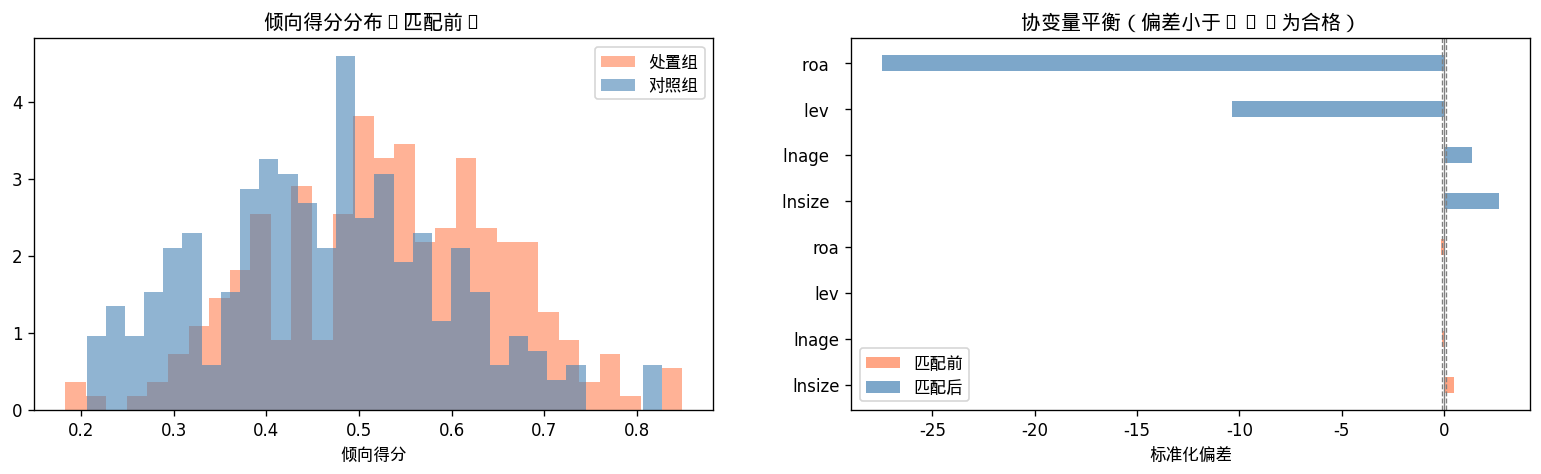

In [3]:
ps = psm._ps  # 倾向得分
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

axes[0].hist(ps[T==1], bins=30, alpha=0.6, color='coral', label='处置组', density=True)
axes[0].hist(ps[T==0], bins=30, alpha=0.6, color='steelblue', label='对照组', density=True)
axes[0].set_xlabel('倾向得分'); axes[0].set_title('倾向得分分布(匹配前)')
axes[0].legend()

# 协变量平衡
matched_idx = psm._matched_idx
X_treat = X[T==1]; X_ctrl = X[matched_idx]
feat = ['lnsize','lnage','lev','roa']
sb_bef = [(X[T==1,j].mean()-X[T==0,j].mean())/X[:,j].std() for j in range(4)]
sb_aft = [(X_treat[:,j].mean()-X_ctrl[:,j].mean())/X[:,j].std() for j in range(4)]
axes[1].barh(feat, sb_bef, 0.35, label='匹配前', color='coral', alpha=0.7)
axes[1].barh([f+'  ' for f in feat], sb_aft, 0.35, label='匹配后', color='steelblue', alpha=0.7)
for v in [-0.1, 0, 0.1]:
    axes[1].axvline(v, ls='--' if v else '-', c='gray', lw=0.8)
axes[1].set_xlabel('标准化偏差'); axes[1].set_title('协变量平衡（偏差小于0.1为合格）')
axes[1].legend()
plt.tight_layout();show()

## 5. 结果解读

匹配后ATT显著为正，政府补贴对R&D投入有因果促进作用，
但效应量小于朴素OLS，印证选择效应导致OLS高估。
协变量平衡检验显示匹配后偏差均<10%，共同支撑成立。

In [4]:
for cal in [0.02, 0.05, 0.10, None]:
    p2 = PSM(caliper=cal, n_neighbors=1)
    p2.fit(X, T, Y)
    s2 = p2.summary()
    cal_str = str(cal) if cal else '无卡尺'
    a2 = s2['ATT']
    print(f'caliper={cal_str:6}  ATT={a2["coef"]:.4f}  p={a2["p_value"]:.4f}')

caliper=0.02    ATT=0.3708  p=0.0000
caliper=0.05    ATT=0.3759  p=0.0000
caliper=0.1     ATT=0.3901  p=0.0000
caliper=无卡尺     ATT=0.5435  p=0.0000


## 6. 可视化

已在第4节生成 `fig_T07_psm.png`。